In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

# Carpeta desde donde Jupyter está ejecutando el notebook
print("Directorio actual:", Path.cwd())

# Ruta correcta si Jupyter fue abierto desde la raíz del repositorio
frame_dir = Path("data/frames/test_20s")

# Si no existe, probar la ruta alternativa si el notebook se ejecuta desde notebooks/
if not frame_dir.exists():
    frame_dir = Path("../data/frames/test_20s")

print("Ruta de frames usada:", frame_dir.resolve())

frames = sorted(frame_dir.glob("*.jpg"))

print(f"Número de frames encontrados: {len(frames)}")

if len(frames) == 0:
    raise FileNotFoundError(
        f"No se encontraron frames en: {frame_dir.resolve()}"
    )

print(f"Primer frame: {frames[0].name}")
print(f"Último frame: {frames[-1].name}")

Directorio actual: /home/eduar/projects/copa-fut-bot-mx-pumas-ae
Ruta de frames usada: /home/eduar/projects/copa-fut-bot-mx-pumas-ae/data/frames/test_20s
Número de frames encontrados: 200
Primer frame: frame_000001.jpg
Último frame: frame_000200.jpg


Dimensiones: (1276, 960, 3)


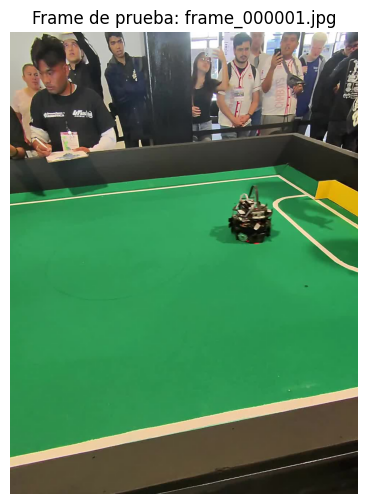

In [2]:
frame_path = frames[0]

img_bgr = cv2.imread(str(frame_path))

if img_bgr is None:
    raise RuntimeError(f"No se pudo leer la imagen: {frame_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Dimensiones:", img_rgb.shape)

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"Frame de prueba: {frame_path.name}")
plt.show()

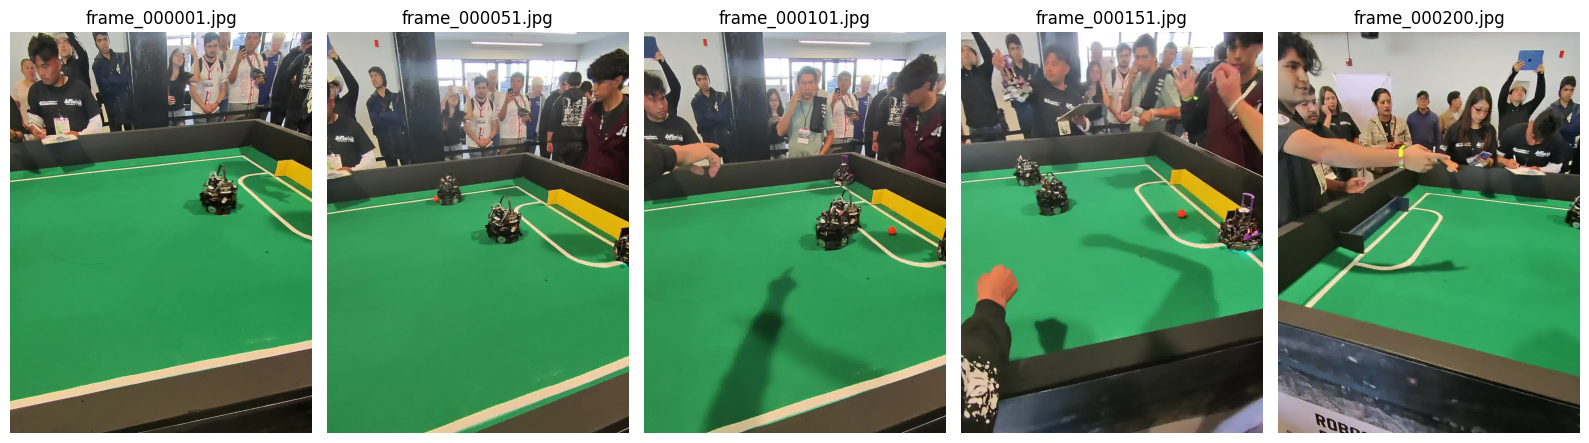

In [3]:
indices = [0, len(frames)//4, len(frames)//2, 3*len(frames)//4, len(frames)-1]

plt.figure(figsize=(16, 8))

for i, idx in enumerate(indices, start=1):
    frame_path = frames[idx]
    img_bgr = cv2.imread(str(frame_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(indices), i)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(frame_path.name)

plt.tight_layout()
plt.show()